In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch import nn
from PIL import Image
from torchvision.models import densenet121 , DenseNet121_Weights
from tqdm.auto import tqdm

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10

label_columns = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices"
]

BASE_DIR = Path("/kaggle/input/datasets/ashery/chexpert")

train_df = pd.read_csv(BASE_DIR / "train.csv")
validation_df = pd.read_csv(BASE_DIR / "valid.csv")

train_df["Path"] = train_df["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

validation_df["Path"] = validation_df["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

train_df[label_columns] = train_df[label_columns].fillna(0)
validation_df[label_columns] = validation_df[label_columns].fillna(0)
train_df[label_columns] = train_df[label_columns].replace(-1, 0)
validation_df[label_columns] = validation_df[label_columns].replace(-1, 0)

class ChestXrayDataset(Dataset):
    def __init__(self,dataframe,root_dir,label_cols,transforms = None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.label_cols = label_cols
        self.transform = transforms

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, key):
        row = self.dataframe.iloc[key]
        image_path = self.root_dir / row["Path"]
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)

        labels = row[self.label_cols].values.astype(np.float32)
        labels = torch.tensor(labels)

        return image,labels
    

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ChestXrayDataset(dataframe = train_df, root_dir = BASE_DIR, label_cols = label_columns, transforms = train_transforms)
validation_dataset = ChestXrayDataset(dataframe = validation_df, root_dir = BASE_DIR, label_cols = label_columns, transforms = val_transforms)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_dataloader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights = weights)

# for param in model.features.parameters():
#     param.requires_grad = False

model.classifier = nn.Linear(in_features = model.classifier.in_features,out_features = len(label_columns))

checkpoint = torch.load(
    "/kaggle/input/datasets/zeeshanwaris/model-weights/chest_xray_checkpoint.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = True

model.to(DEVICE)

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

best_val_loss = float("inf")

start_epoch = checkpoint['epoch']

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2,
)

scaler = torch.amp.GradScaler("cuda")

train_losses = []
val_losses = []

for epoch in range(start_epoch,EPOCHS+start_epoch):
    train_loss = 0.0
    model.train()
    for batch_idx , (images,labels) in enumerate(train_dataloader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss = loss_fn(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Train Batch no : {batch_idx}")

    val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for batch_idx, (images,labels) in enumerate(val_dataloader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with torch.amp.autocast("cuda"):
                logits = model(images)
                loss = loss_fn(logits,labels)

            val_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Validation Batch no : {batch_idx}")

    avg_train_loss = train_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_loss": best_val_loss,
        }, "/kaggle/working/best_densenet_checkpoint.pth")

        print("✓ Best model saved")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 179MB/s]


Train Batch no : 0
Train Batch no : 100
Train Batch no : 200
Train Batch no : 300
Train Batch no : 400
Train Batch no : 500
Train Batch no : 600
Train Batch no : 700
Train Batch no : 800
Train Batch no : 900
Train Batch no : 1000
Train Batch no : 1100
Train Batch no : 1200
Train Batch no : 1300
Train Batch no : 1400
Train Batch no : 1500
Train Batch no : 1600
Train Batch no : 1700
Validation Batch no : 0
Epoch 4 | Train: 0.3058 | Val: 0.4083 | LR: 1.00e-05
✓ Best model saved
Train Batch no : 0
Train Batch no : 100
Train Batch no : 200
Train Batch no : 300
Train Batch no : 400
Train Batch no : 500
Train Batch no : 600
Train Batch no : 700
Train Batch no : 800
Train Batch no : 900
Train Batch no : 1000
Train Batch no : 1100
Train Batch no : 1200
Train Batch no : 1300
Train Batch no : 1400
Train Batch no : 1500
Train Batch no : 1600
Train Batch no : 1700
Validation Batch no : 0
Epoch 5 | Train: 0.2918 | Val: 0.4008 | LR: 1.00e-05
✓ Best model saved
Train Batch no : 0
Train Batch no : 100


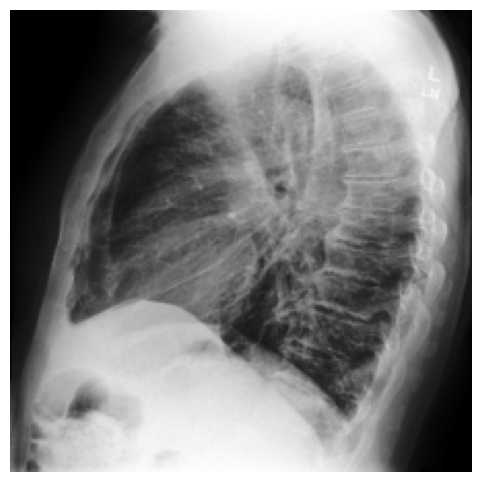

No Finding                     Prob=0.099 Pred=0
Enlarged Cardiomediastinum     Prob=0.048 Pred=0
Cardiomegaly                   Prob=0.024 Pred=0
Lung Opacity                   Prob=0.424 Pred=0
Lung Lesion                    Prob=0.109 Pred=0
Edema                          Prob=0.022 Pred=0
Consolidation                  Prob=0.045 Pred=0
Pneumonia                      Prob=0.058 Pred=0
Atelectasis                    Prob=0.053 Pred=0
Pneumothorax                   Prob=0.044 Pred=0
Pleural Effusion               Prob=0.050 Pred=0
Pleural Other                  Prob=0.097 Pred=0
Fracture                       Prob=0.081 Pred=0
Support Devices                Prob=0.090 Pred=0

Ground truth:
- Lung Opacity
- Pneumothorax


In [17]:
checkpoint = torch.load("/kaggle/working/best_densenet_checkpoint.pth", map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

# Get one validation sample
img, label = validation_dataset[9]

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(DEVICE))
    probs = torch.sigmoid(logits).cpu().squeeze(0)

predictions = (probs >= 0.5).int()

# Convert image back to displayable format
img_disp = img.permute(1, 2, 0).cpu().numpy()

# Undo normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_disp = std * img_disp + mean
img_disp = np.clip(img_disp, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(img_disp)
plt.axis("off")
plt.show()

# Print probabilities
for disease, p, pred in zip(label_columns, probs, predictions):
    print(f"{disease:30} Prob={p.item():.3f} Pred={pred.item()}")

print("\nGround truth:")
for disease, gt in zip(label_columns, label):
    if gt == 1:
        print("-", disease)

In [19]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
)

# Put model in evaluation mode
model.eval()

all_labels = []
all_probs = []

# -----------------------------
# Collect predictions
# -----------------------------
with torch.no_grad():

    for images, labels in val_dataloader:

        images = images.to(DEVICE)

        logits = model(images)

        probs = torch.sigmoid(logits)

        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

# Merge all batches
all_labels = torch.cat(all_labels)
all_probs = torch.cat(all_probs)

# Convert to NumPy
y_true = all_labels.numpy()
y_scores = all_probs.numpy()

# -----------------------------
# ROC-AUC
# -----------------------------
print("=" * 60)
print("ROC-AUC PER DISEASE")
print("=" * 60)

aucs = []

for i, disease in enumerate(label_columns):

    try:
        auc = roc_auc_score(y_true[:, i], y_scores[:, i])
        aucs.append(auc)
        print(f"{disease:30} {auc:.4f}")

    except ValueError:
        print(f"{disease:30} Undefined (only one class present)")

print("=" * 60)
valid_aucs = []

for i, disease in enumerate(label_columns):
    try:
        auc = roc_auc_score(y_true[:, i], y_scores[:, i])
        valid_aucs.append(auc)
        print(f"{disease:30} {auc:.4f}")
    except ValueError:
        print(f"{disease:30} Undefined")

print(f"\nMean ROC-AUC: {np.mean(valid_aucs):.4f}")

# -----------------------------
# Precision / Recall / F1
# -----------------------------
threshold = 0.5

y_pred = (y_scores >= threshold).astype(int)

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_columns,
        zero_division=0
    )
)

ROC-AUC PER DISEASE
No Finding                     0.9041
Enlarged Cardiomediastinum     0.5698
Cardiomegaly                   0.8234
Lung Opacity                   0.9122
Lung Lesion                    0.1416
Edema                          0.9037
Consolidation                  0.8872
Pneumonia                      0.7655
Atelectasis                    0.7838
Pneumothorax                   0.7644
Pleural Effusion               0.9294
Pleural Other                  0.9399
Fracture                       nan
Support Devices                0.8895
No Finding                     0.9041
Enlarged Cardiomediastinum     0.5698
Cardiomegaly                   0.8234
Lung Opacity                   0.9122
Lung Lesion                    0.1416
Edema                          0.9037
Consolidation                  0.8872
Pneumonia                      0.7655
Atelectasis                    0.7838
Pneumothorax                   0.7644
Pleural Effusion               0.9294
Pleural Other                  0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [20]:
from sklearn.metrics import f1_score

best_thresholds = []

for i, disease in enumerate(label_columns):

    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.0, 1.01, 0.01):

        predictions = (y_scores[:, i] >= threshold).astype(int)

        score = f1_score(
            y_true[:, i],
            predictions,
            zero_division=0
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    best_thresholds.append(best_threshold)

    print(
        f"{disease:30}"
        f" Threshold={best_threshold:.2f}"
        f" F1={best_f1:.3f}"
    )

No Finding                     Threshold=0.30 F1=0.643
Enlarged Cardiomediastinum     Threshold=0.00 F1=0.636
Cardiomegaly                   Threshold=0.05 F1=0.639
Lung Opacity                   Threshold=0.28 F1=0.853
Lung Lesion                    Threshold=0.01 F1=0.010
Edema                          Threshold=0.27 F1=0.699
Consolidation                  Threshold=0.07 F1=0.565
Pneumonia                      Threshold=0.04 F1=0.157
Atelectasis                    Threshold=0.15 F1=0.648
Pneumothorax                   Threshold=0.14 F1=0.167
Pleural Effusion               Threshold=0.39 F1=0.760
Pleural Other                  Threshold=0.05 F1=0.125
Fracture                       Threshold=0.50 F1=0.000
Support Devices                Threshold=0.35 F1=0.814


In [22]:
best_thresholds = np.array(best_thresholds)

y_pred = (y_scores >= best_thresholds).astype(int)

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_columns,
        zero_division=0
    )
)



CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                No Finding       0.59      0.71      0.64        38
Enlarged Cardiomediastinum       0.47      1.00      0.64       109
              Cardiomegaly       0.53      0.79      0.64        68
              Lung Opacity       0.78      0.94      0.85       126
               Lung Lesion       0.00      1.00      0.01         1
                     Edema       0.62      0.80      0.70        45
             Consolidation       0.44      0.79      0.57        33
                 Pneumonia       0.09      0.50      0.16         8
               Atelectasis       0.59      0.71      0.65        80
              Pneumothorax       0.11      0.38      0.17         8
          Pleural Effusion       0.79      0.73      0.76        67
             Pleural Other       0.07      1.00      0.12         1
                  Fracture       0.00      0.00      0.00         0
           Support Devi